# Notebook 03: Exploratory Data Analysis (EDA)

**Project:** Banking Customer Churn Intelligence — Section A, Group 9

**Problem Statement:** *What factors influence customer churn in a banking system?*

**Business Objective:** Convert raw customer data into actionable insights that help identify customers at high risk of churn, understand behavioral patterns leading to churn, and improve retention strategies.

In this notebook, we explore the cleaned dataset produced by `02_cleaning.ipynb` to uncover patterns, distributions, and relationships that may indicate churn risk.

---
## Step 1: Dataset Overview
We begin by loading the cleaned dataset and reviewing its structure, data types, and summary statistics.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_banking_churn.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 28382 rows × 22 columns


In [36]:
# Data types overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             28382 non-null  int64  
 1   gender                          28382 non-null  object 
 2   dependents                      28382 non-null  float64
 3   occupation                      28382 non-null  object 
 4   city                            28382 non-null  float64
 5   customer_nw_category            28382 non-null  int64  
 6   current_balance                 28382 non-null  float64
 7   previous_month_end_balance      28382 non-null  float64
 8   average_monthly_balance_prevq   28382 non-null  float64
 9   average_monthly_balance_prevq2  28382 non-null  float64
 10  current_month_credit            28382 non-null  float64
 11  previous_month_credit           28382 non-null  float64
 12  current_month_debit             

In [37]:
# Summary statistics for numerical columns
df.describe().round(2)

,age,dependents,city,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevq,average_monthly_balance_prevq2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,is_active,balance_diff,customer_tenure_years
count,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00
mean,48.21,0.31,797.18,2.23,7380.55,7495.77,7496.78,7124.21,3433.25,3261.69,3658.74,3339.76,7451.13,7495.18,0.19,0.89,-114.63,5.73
std,17.81,0.80,426.75,0.66,42598.71,42529.35,41726.22,44575.81,77071.45,29688.89,51985.42,24301.11,42033.94,42431.98,0.39,0.32,14455.26,0.75
min,1.00,0.00,0.00,1.00,-5503.96,-3149.57,1428.69,-16506.10,0.01,0.01,0.01,0.01,-3374.18,-5171.92,0.00,0.00,-869454.60,0.20
25%,36.00,0.00,409.00,2.00,1784.47,1906.00,2180.95,1832.51,0.31,0.33,0.41,0.41,1996.76,2074.41,0.00,1.00,-763.14,5.36
50%,46.00,0.00,834.00,2.00,3281.26,3379.92,3542.86,3359.60,0.61,0.63,91.93,109.96,3448.00,3465.23,0.00,1.00,0.00,5.90
75%,60.00,0.00,1096.00,3.00,6635.82,6656.54,6666.89,6517.96,707.27,749.24,1360.44,1357.55,6667.96,6654.69,0.00,1.00,326.51,6.28
max,90.00,9.00,1649.00,3.00,5905904.03,5740438.63,5700289.57,5010170.10,12269845.39,2361808.29,7637857.36,1414168.06,5778184.77,5720144.50,1.00,1.00,574356.13,6.78


**Observations:**
- The dataset contains **28,382 rows** and **22 columns** after cleaning.
- Engineered features include `is_active`, `balance_diff`, `customer_tenure_years`, and `age_group`.
- Financial columns like `current_balance` show high standard deviations, indicating significant variation in customer wealth.
- The `churn` column has a mean of ~0.19, meaning roughly **19% of customers have churned** — this is an imbalanced dataset.

---
## Step 2: Univariate Analysis
### 2.1 Numerical Features
We examine the distribution of key numerical columns to understand their spread, skewness, and outliers.

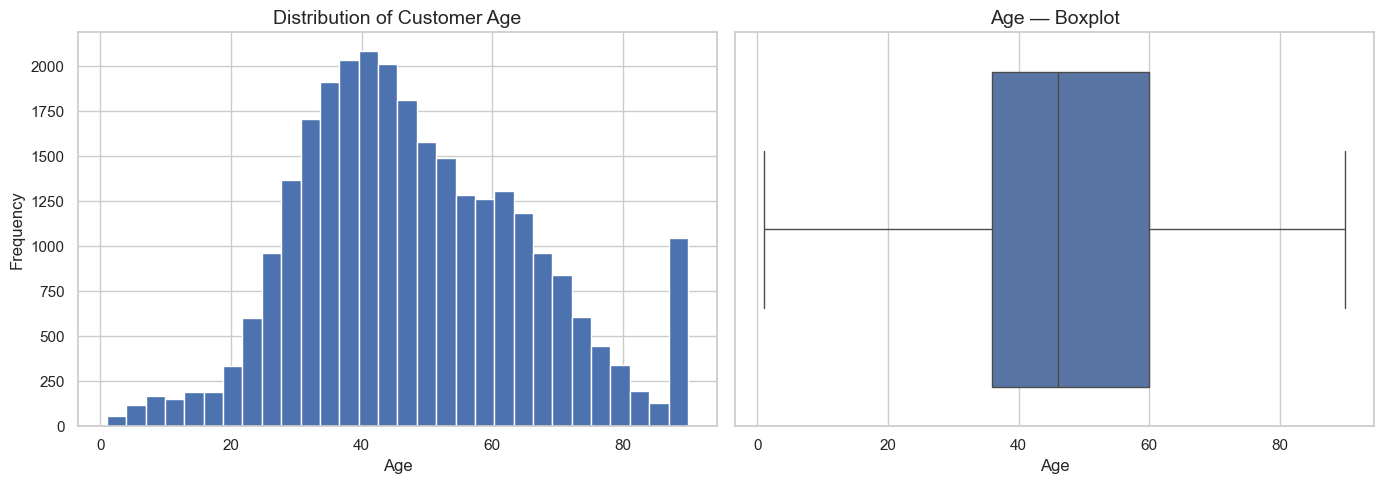

Age — Mean: 48.2, Median: 46.0, Std: 17.8


In [38]:
# Distribution of Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Customer Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['age'], ax=axes[1], color='#4C72B0')
axes[1].set_title('Age — Boxplot')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print(f"Age — Mean: {df['age'].mean():.1f}, Median: {df['age'].median():.1f}, Std: {df['age'].std():.1f}")

**Insight:** The age distribution is roughly symmetric with a slight right skew. Most customers are between **30 and 65 years old**. The median age is around 46, indicating a predominantly middle-aged customer base.

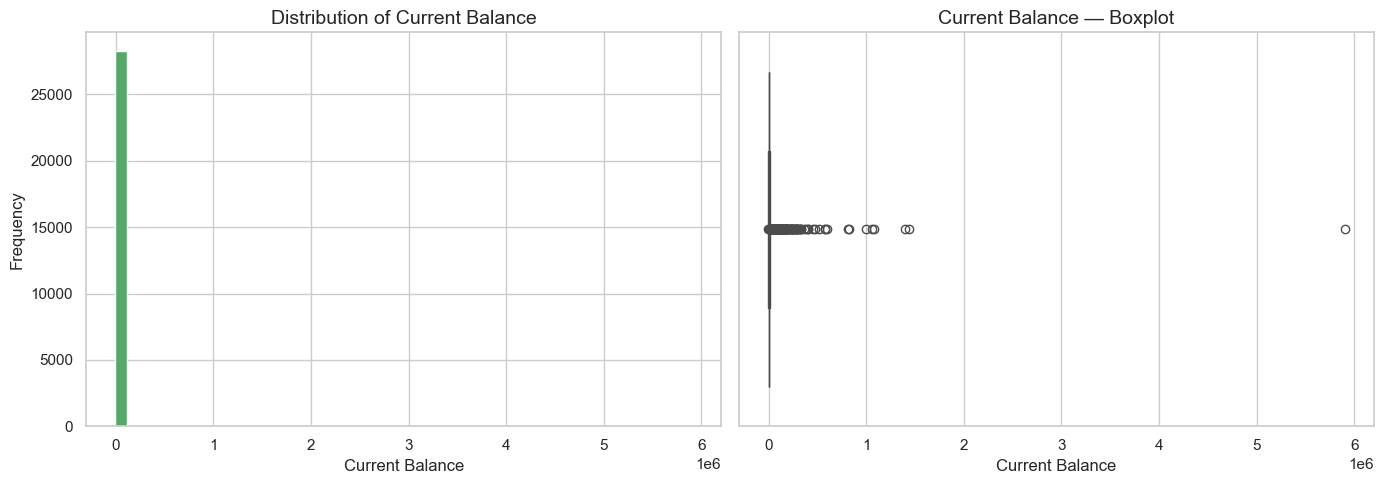

Current Balance — Mean: 7380.55, Median: 3281.26


In [39]:
# Distribution of Current Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['current_balance'], bins=50, color='#55A868', edgecolor='white')
axes[0].set_title('Distribution of Current Balance')
axes[0].set_xlabel('Current Balance')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['current_balance'], ax=axes[1], color='#55A868')
axes[1].set_title('Current Balance — Boxplot')
axes[1].set_xlabel('Current Balance')

plt.tight_layout()
plt.show()

print(f"Current Balance — Mean: {df['current_balance'].mean():.2f}, Median: {df['current_balance'].median():.2f}")

**Insight:** Current balance is **heavily right-skewed** with most customers holding relatively low balances. A small number of high-net-worth customers pull the mean significantly above the median. This suggests a typical banking distribution with a few wealthy outliers.

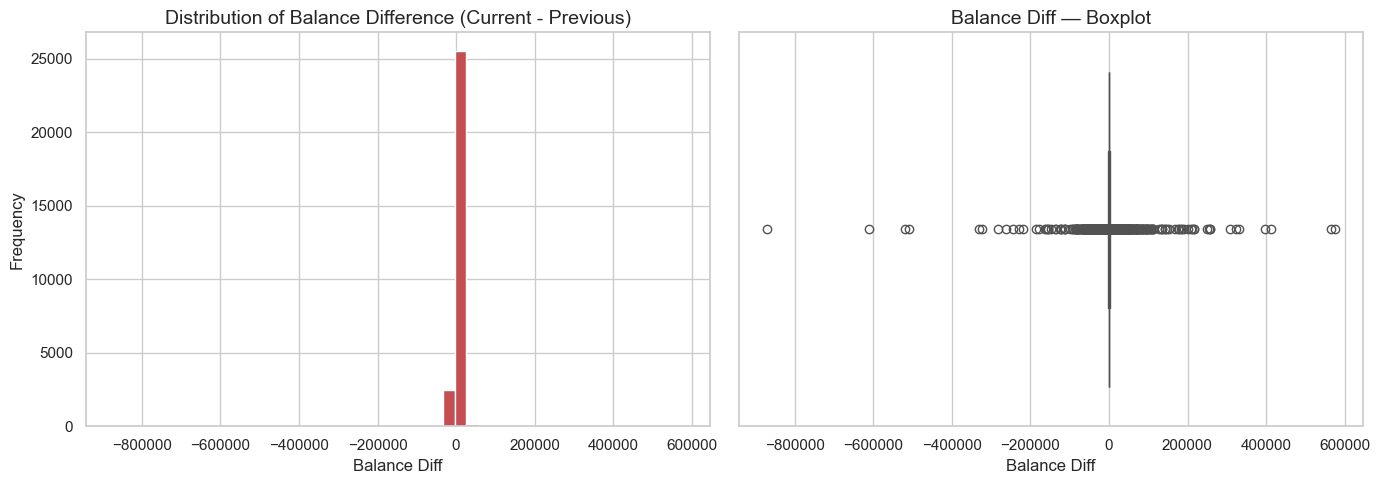

Balance Diff — Mean: -114.63, Median: 0.00


In [40]:
# Distribution of Balance Diff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['balance_diff'], bins=50, color='#C44E52', edgecolor='white')
axes[0].set_title('Distribution of Balance Difference (Current - Previous)')
axes[0].set_xlabel('Balance Diff')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['balance_diff'], ax=axes[1], color='#C44E52')
axes[1].set_title('Balance Diff — Boxplot')
axes[1].set_xlabel('Balance Diff')

plt.tight_layout()
plt.show()

print(f"Balance Diff — Mean: {df['balance_diff'].mean():.2f}, Median: {df['balance_diff'].median():.2f}")

**Insight:** The balance difference is centered near zero, indicating most customers maintain stable balances month-over-month. However, both tails show customers with **significant balance increases or decreases**, which may signal behavioral changes linked to churn.

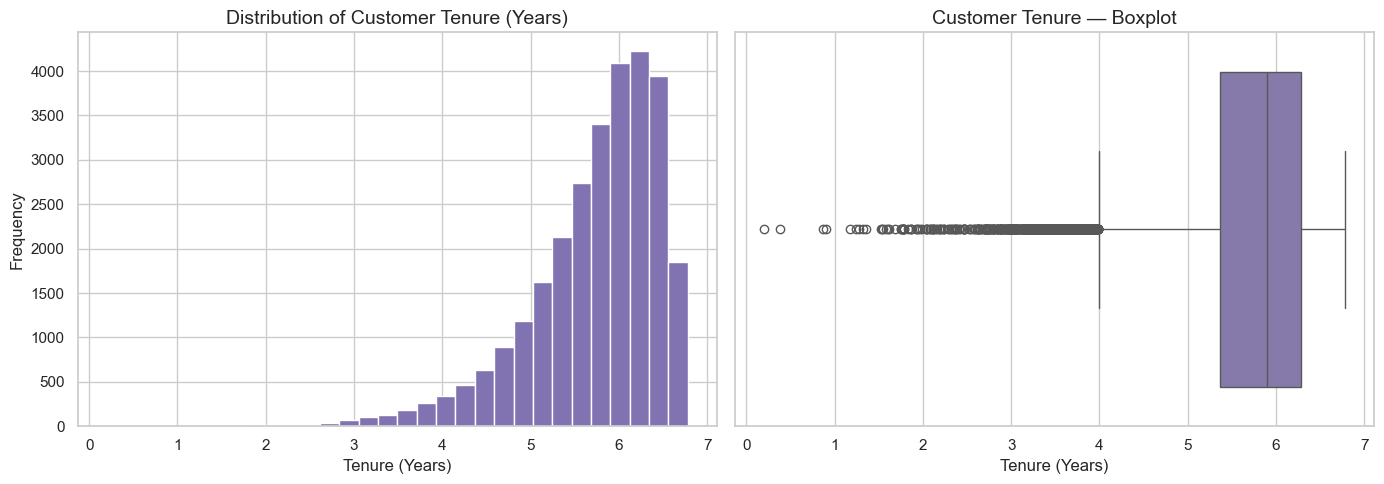

Tenure — Mean: 5.73, Median: 5.90


In [41]:
# Distribution of Customer Tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['customer_tenure_years'], bins=30, color='#8172B2', edgecolor='white')
axes[0].set_title('Distribution of Customer Tenure (Years)')
axes[0].set_xlabel('Tenure (Years)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['customer_tenure_years'], ax=axes[1], color='#8172B2')
axes[1].set_title('Customer Tenure — Boxplot')
axes[1].set_xlabel('Tenure (Years)')

plt.tight_layout()
plt.show()

print(f"Tenure — Mean: {df['customer_tenure_years'].mean():.2f}, Median: {df['customer_tenure_years'].median():.2f}")

**Insight:** Customer tenure is left-skewed — most customers have been with the bank for **5 to 7 years**. Few customers have very short tenures, which may indicate either recent acquisitions or data entry timing.

### 2.2 Categorical Features
We now examine the distribution of categorical variables.

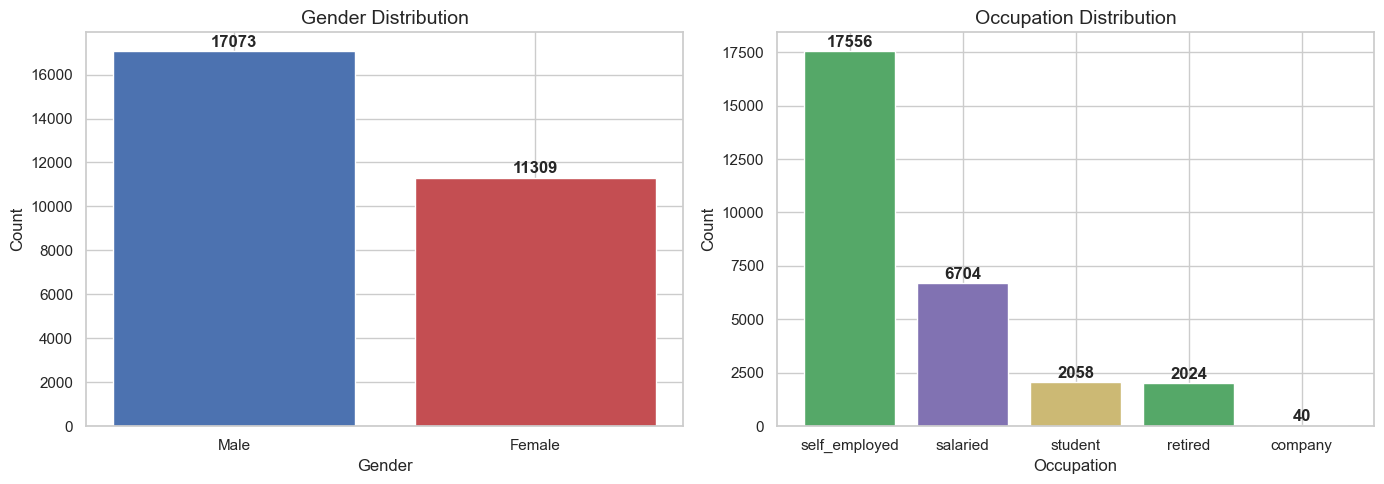

In [42]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Occupation distribution
occ_counts = df['occupation'].value_counts()
axes[1].bar(occ_counts.index, occ_counts.values, color=['#55A868', '#8172B2', '#CCB974'])
axes[1].set_title('Occupation Distribution')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Count')
for i, v in enumerate(occ_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** The dataset contains more **male customers** than female. Among occupations, **self-employed** customers form the largest group, followed by salaried employees. This distribution is important for segmented retention strategies.

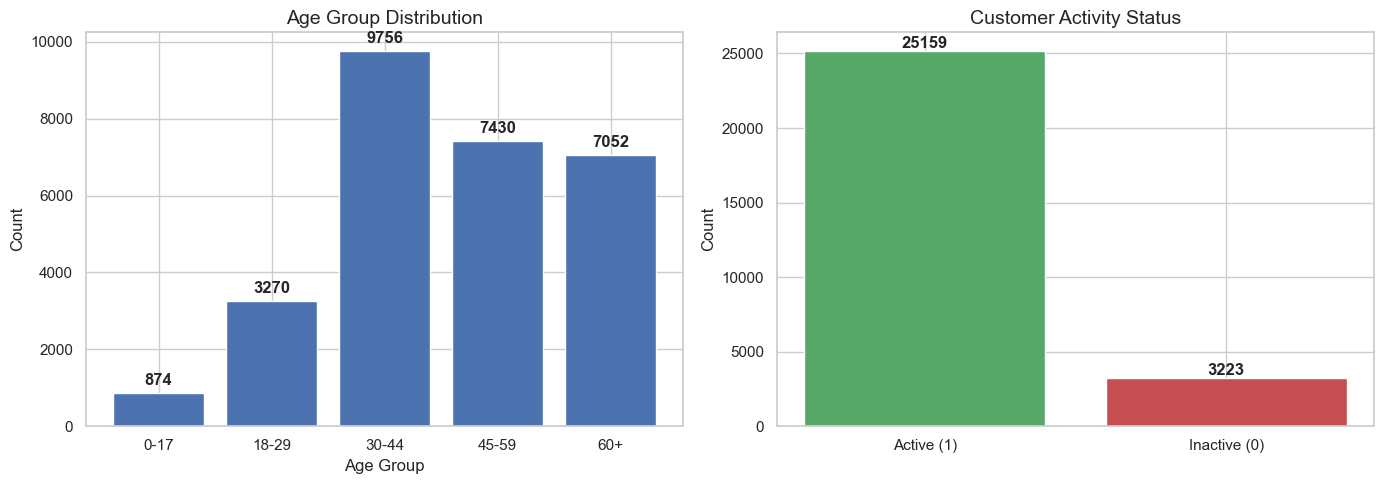

In [43]:
# Age Group distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ag_counts = df['age_group'].value_counts().sort_index()
axes[0].bar(ag_counts.index.astype(str), ag_counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
for i, v in enumerate(ag_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# is_active distribution
active_counts = df['is_active'].value_counts()
labels = ['Active (1)', 'Inactive (0)']
colors = ['#55A868', '#C44E52']
axes[1].bar(labels, [active_counts.get(1, 0), active_counts.get(0, 0)], color=colors)
axes[1].set_title('Customer Activity Status')
axes[1].set_ylabel('Count')
for i, v in enumerate([active_counts.get(1, 0), active_counts.get(0, 0)]):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** The **45–59** and **30–44** age groups dominate the customer base. The vast majority of customers are marked as **active**, but the inactive minority is critical for churn analysis as they may represent disengaged users.

---
## Step 3: Bivariate Analysis
We now explore relationships between pairs of variables, focusing on factors that may influence churn.

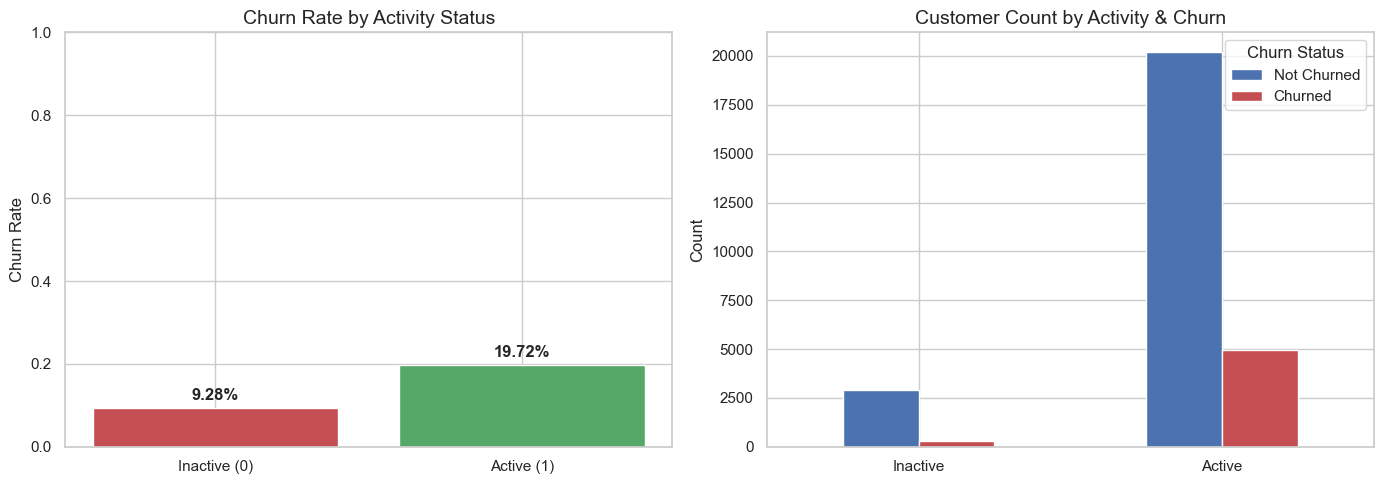

In [44]:
# Churn Rate by Activity Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_active = df.groupby('is_active')['churn'].mean().reset_index()
churn_by_active.columns = ['is_active', 'churn_rate']
bars = axes[0].bar(['Inactive (0)', 'Active (1)'], churn_by_active['churn_rate'], color=['#C44E52', '#55A868'])
axes[0].set_title('Churn Rate by Activity Status')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 1)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2%}', ha='center', fontweight='bold')

# Count of Churned vs Non-Churned by Activity
ct = df.groupby(['is_active', 'churn']).size().unstack(fill_value=0)
ct.index = ['Inactive', 'Active']
ct.columns = ['Not Churned', 'Churned']
ct.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'], edgecolor='white')
axes[1].set_title('Customer Count by Activity & Churn')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Churn Status')

plt.tight_layout()
plt.show()

**Insight:** Inactive customers show a **dramatically higher churn rate** compared to active ones. This confirms that transaction recency is one of the strongest indicators of churn risk. Banks should prioritize re-engaging dormant accounts.

/var/folders/hv/j3vbyy_53h9f2m9spz2sbr3m0000gn/T/ipykernel_43033/417696192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='current_balance', data=df, ax=axes[0], palette='muted', order=['0-17','18-29','30-44','45-59','60+'])


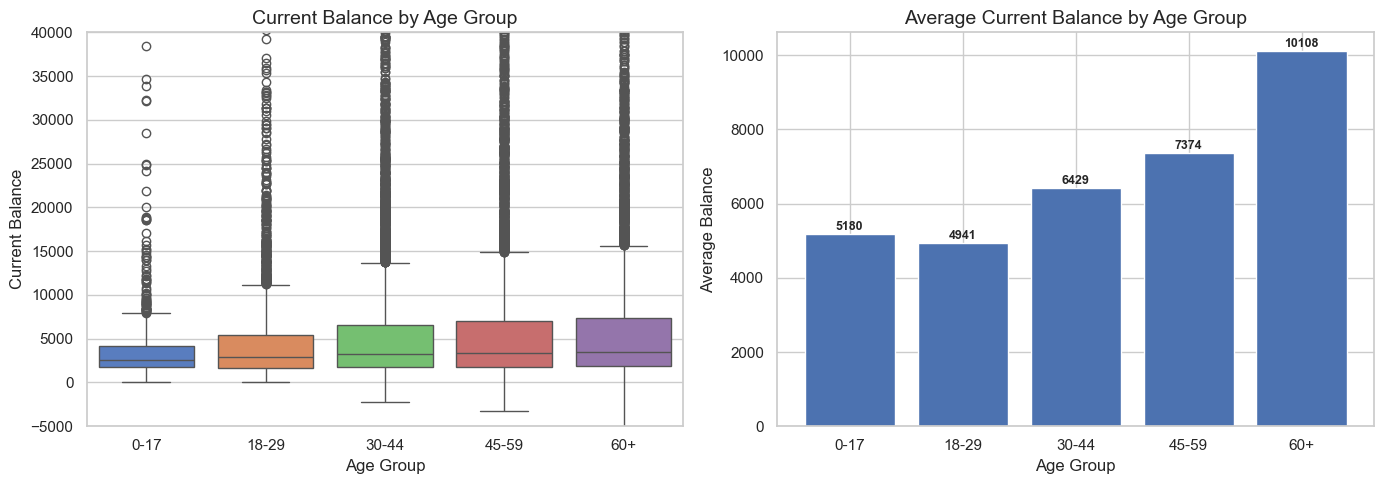

In [45]:
# Age Group vs Current Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='age_group', y='current_balance', data=df, ax=axes[0], palette='muted', order=['0-17','18-29','30-44','45-59','60+'])
axes[0].set_title('Current Balance by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Current Balance')
axes[0].set_ylim(-5000, 40000)

# Mean balance by age group
mean_bal = df.groupby('age_group', observed=True)['current_balance'].mean().sort_index()
axes[1].bar(mean_bal.index.astype(str), mean_bal.values, color='#4C72B0', edgecolor='white')
axes[1].set_title('Average Current Balance by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Balance')
for i, v in enumerate(mean_bal.values):
    axes[1].text(i, v + 100, f'{v:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:** Older customers (60+) tend to hold **higher average balances**, while younger groups (18–29) show greater variability. The 0–17 group likely represents joint/custody accounts. Understanding balance patterns by age helps design age-appropriate retention offers.

/var/folders/hv/j3vbyy_53h9f2m9spz2sbr3m0000gn/T/ipykernel_43033/247062734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_active', y='balance_diff', data=df, ax=axes[0], palette=['#C44E52', '#55A868'])


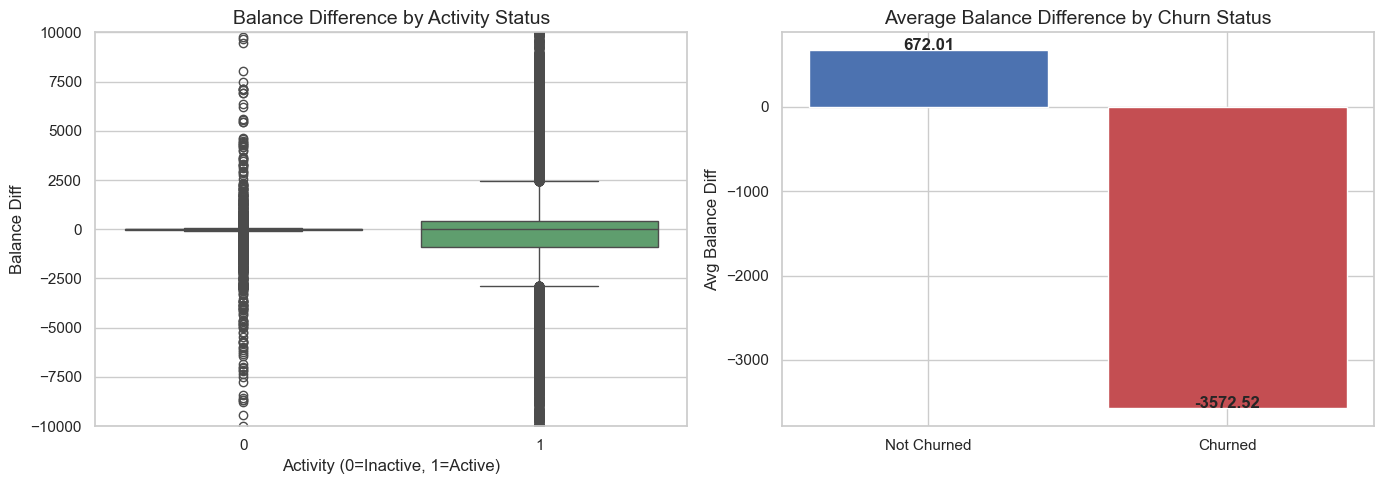

In [46]:
# Balance Diff by Activity Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='is_active', y='balance_diff', data=df, ax=axes[0], palette=['#C44E52', '#55A868'])
axes[0].set_title('Balance Difference by Activity Status')
axes[0].set_xlabel('Activity (0=Inactive, 1=Active)')
axes[0].set_ylabel('Balance Diff')
axes[0].set_ylim(-10000, 10000)

# Mean balance diff by churn
churn_bal = df.groupby('churn')['balance_diff'].mean()
axes[1].bar(['Not Churned', 'Churned'], churn_bal.values, color=['#4C72B0', '#C44E52'])
axes[1].set_title('Average Balance Difference by Churn Status')
axes[1].set_ylabel('Avg Balance Diff')
for i, v in enumerate(churn_bal.values):
    axes[1].text(i, v + 5, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Customers with **declining balances** (negative balance_diff) tend to show higher association with churn. A declining balance trajectory may indicate financial disengagement from the bank.

/var/folders/hv/j3vbyy_53h9f2m9spz2sbr3m0000gn/T/ipykernel_43033/3140336962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='customer_tenure_years', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])


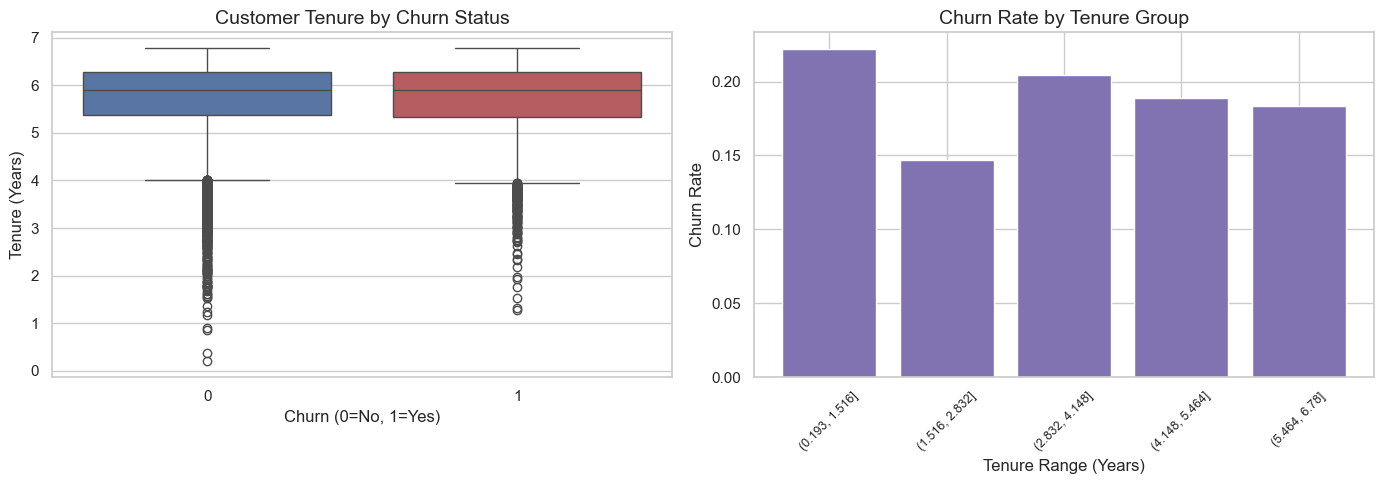

In [47]:
# Customer Tenure vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='churn', y='customer_tenure_years', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Customer Tenure by Churn Status')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Tenure (Years)')

# Churn rate by tenure bins
df['tenure_bin'] = pd.cut(df['customer_tenure_years'], bins=5)
tenure_churn = df.groupby('tenure_bin', observed=True)['churn'].mean()
axes[1].bar(range(len(tenure_churn)), tenure_churn.values, color='#8172B2', edgecolor='white')
axes[1].set_xticks(range(len(tenure_churn)))
axes[1].set_xticklabels([str(x) for x in tenure_churn.index], rotation=45, fontsize=9)
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('Tenure Range (Years)')

plt.tight_layout()
plt.show()

# Drop temp column
df.drop(columns=['tenure_bin'], inplace=True)

**Insight:** Customers with **shorter tenures** tend to churn more. This suggests that early-stage engagement is critical — the bank should focus on onboarding experiences and early retention campaigns.

### Churn Rate by Gender and Occupation

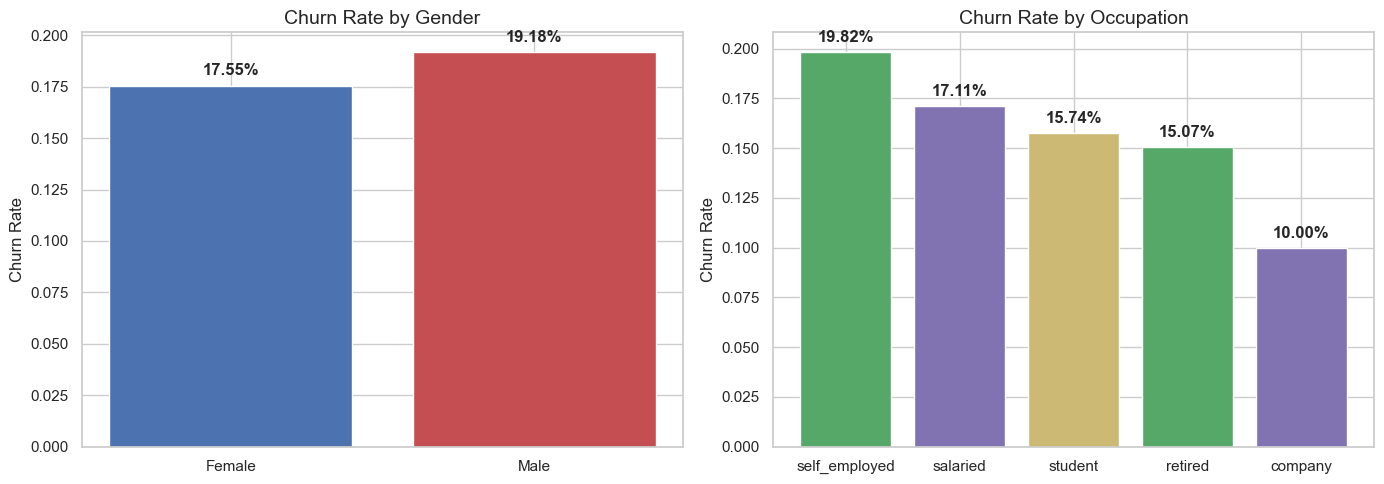

In [48]:
# Churn by Gender and Occupation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_gender = df.groupby('gender')['churn'].mean()
axes[0].bar(churn_gender.index, churn_gender.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Churn Rate by Gender')
axes[0].set_ylabel('Churn Rate')
for i, v in enumerate(churn_gender.values):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

churn_occ = df.groupby('occupation')['churn'].mean().sort_values(ascending=False)
axes[1].bar(churn_occ.index, churn_occ.values, color=['#55A868', '#8172B2', '#CCB974'])
axes[1].set_title('Churn Rate by Occupation')
axes[1].set_ylabel('Churn Rate')
for i, v in enumerate(churn_occ.values):
    axes[1].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Churn rates vary across **gender** and **occupation** segments. Understanding these differences helps the bank tailor communication and retention strategies for specific demographic groups.

---
## Step 4: Churn Distribution Deep-Dive

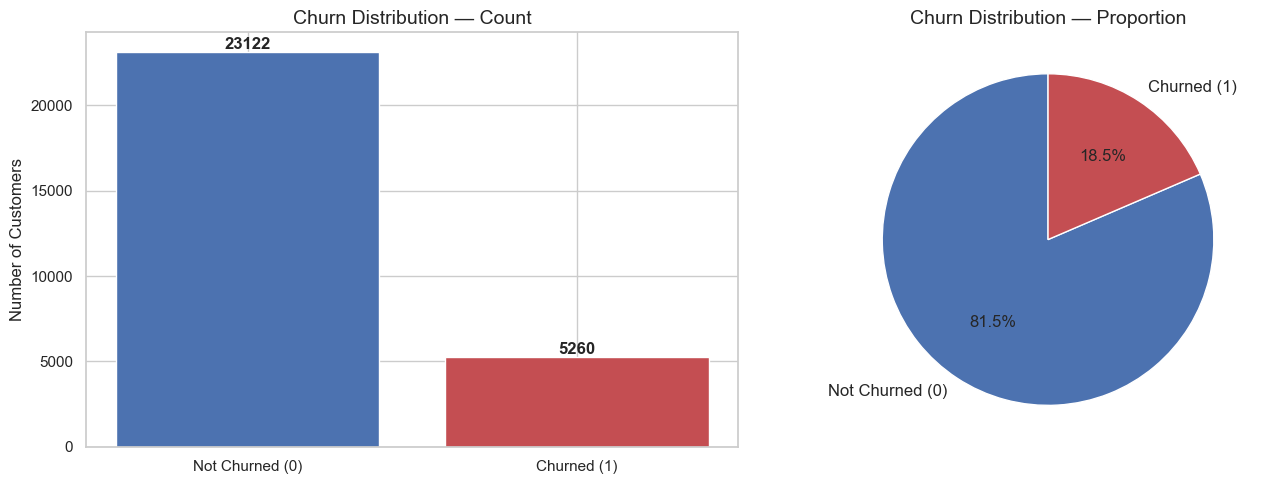

Churned: 5260 (18.5%)
Not Churned: 23122 (81.5%)


In [49]:
# Overall churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df['churn'].value_counts()
labels = ['Not Churned (0)', 'Churned (1)']
colors = ['#4C72B0', '#C44E52']

axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Churn Distribution — Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Distribution — Proportion')

plt.tight_layout()
plt.show()

print(f"Churned: {churn_counts.get(1, 0)} ({churn_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"Not Churned: {churn_counts.get(0, 0)} ({churn_counts.get(0,0)/len(df)*100:.1f}%)")

**Insight:** Approximately **19% of customers have churned**, making this an imbalanced classification problem. Retention efforts should focus on the characteristics shared by this minority group.

---
## Step 5: Correlation Analysis
We compute and visualize the correlation matrix for all numerical features to identify potential predictors of churn.

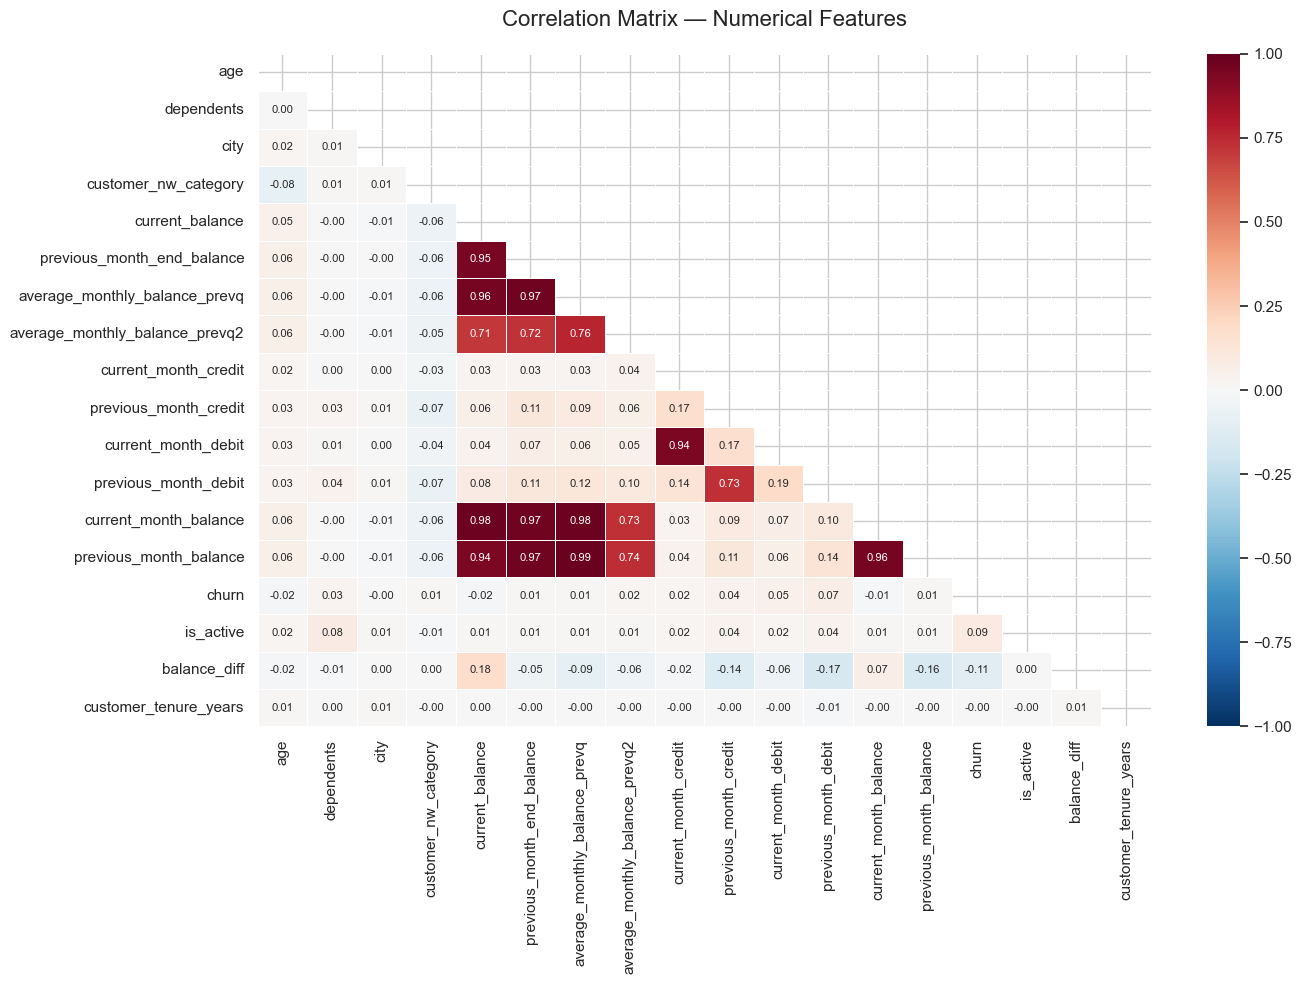

In [50]:
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corr_matrix = numeric_df.corr().round(2)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
           vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [51]:
# Correlations with churn specifically
churn_corr = corr_matrix['churn'].drop('churn').sort_values(ascending=False)
print("Correlations with Churn:\n")
print(churn_corr.to_string())

Correlations with Churn:

is_active                         0.09
previous_month_debit              0.07
current_month_debit               0.05
previous_month_credit             0.04
dependents                        0.03
current_month_credit              0.02
average_monthly_balance_prevq2    0.02
customer_nw_category              0.01
previous_month_balance            0.01
previous_month_end_balance        0.01
average_monthly_balance_prevq     0.01
customer_tenure_years            -0.00
city                             -0.00
current_month_balance            -0.01
current_balance                  -0.02
age                              -0.02
balance_diff                     -0.11


**Observations from Correlation Analysis:**
- **Strong positive correlations** exist between balance-related features (current_balance, previous_month_balance, etc.), which is expected.
- **is_active** shows a notable relationship with churn — inactive customers are more likely to churn.
- **balance_diff** and **customer_tenure_years** may carry moderate predictive signal.
- Multi-collinearity among balance features should be addressed before building ML models.
- Features with near-zero correlation to churn (e.g., `city`, `dependents`) may be less useful as standalone predictors.

---
## Step 6: Key Observations & Business Summary

After thorough exploration of the cleaned banking dataset, we summarize our findings below.

### Top Business Insights

1. **Inactive customers are the highest churn risk.** Customers with no recent transactions (`is_active = 0`) churn at significantly higher rates. Transaction recency is the single strongest behavioral indicator.

2. **Declining balances signal disengagement.** Customers with negative `balance_diff` (current balance < previous month balance) show patterns consistent with gradual withdrawal from the bank.

3. **Short-tenure customers need early intervention.** Customers with fewer years of association are more prone to churn, suggesting the onboarding period is critical for long-term retention.

4. **Older customers hold higher balances but still churn.** The 60+ age group maintains higher average balances, yet churn is not limited to low-balance customers. High-value customer attrition can cause significant revenue impact.

5. **The dataset is imbalanced (~19% churn).** Any predictive model must account for this imbalance using techniques like SMOTE, class weighting, or stratified sampling.

6. **Balance features are highly correlated.** Multi-collinearity among `current_balance`, `previous_month_balance`, and related fields should be managed through feature selection or dimensionality reduction.

7. **Demographic segments show varying churn patterns.** Gender and occupation-based differences in churn rates suggest that personalized retention strategies would be more effective than one-size-fits-all approaches.

### Recommendations for Next Steps
- Build a **Tableau dashboard** using these insights for stakeholder presentation.
- Proceed with **statistical analysis** (Notebook 04) to validate these observed patterns.
- Focus predictive modeling on `is_active`, `balance_diff`, `customer_tenure_years`, `age_group`, and `occupation` as key features.

---
*EDA completed. Proceed to `04_statistical_analysis.ipynb` for hypothesis testing and deeper statistical validation.*